IMPROVED COVID-19 PREDICTION MODEL

Step 1: Loading data...
Loading data from dataset.xlsx...
Dataset shape: (5644, 115)
COVID-19 positive cases: 558 (9.89%)

Step 2: Selecting features...

Step 3: Preprocessing data...
Training set: 4515 samples
Testing set: 1129 samples
Using 18 available features
After filtering - Training set: 4515 samples
After filtering - Testing set: 1129 samples

Step 4: Training models...
Class distribution: 446 positive, 4069 negative (weight=9.12)

Cross-validation results:
Logistic Regression: AUC = 0.6344 ± 0.0171
SVM: AUC = 0.5779 ± 0.0065
Random Forest: AUC = 0.6595 ± 0.0098
Gradient Boosting: AUC = 0.6672 ± 0.0157
XGBoost: AUC = 0.6579 ± 0.0115

Test set evaluation:
Logistic Regression: AUC=0.6337, Sens=0.8036, Spec=0.4326, F1=0.2311
SVM: AUC=0.6068, Sens=0.9196, Spec=0.2684, F1=0.2148
Random Forest: AUC=0.6630, Sens=0.7321, Spec=0.5064, F1=0.2356
Top features: ['age_quantile', 'Leukocytes', 'Platelets', 'Eosinophils', 'SII', 'Monocytes', 'Age_CRP', 'Pr

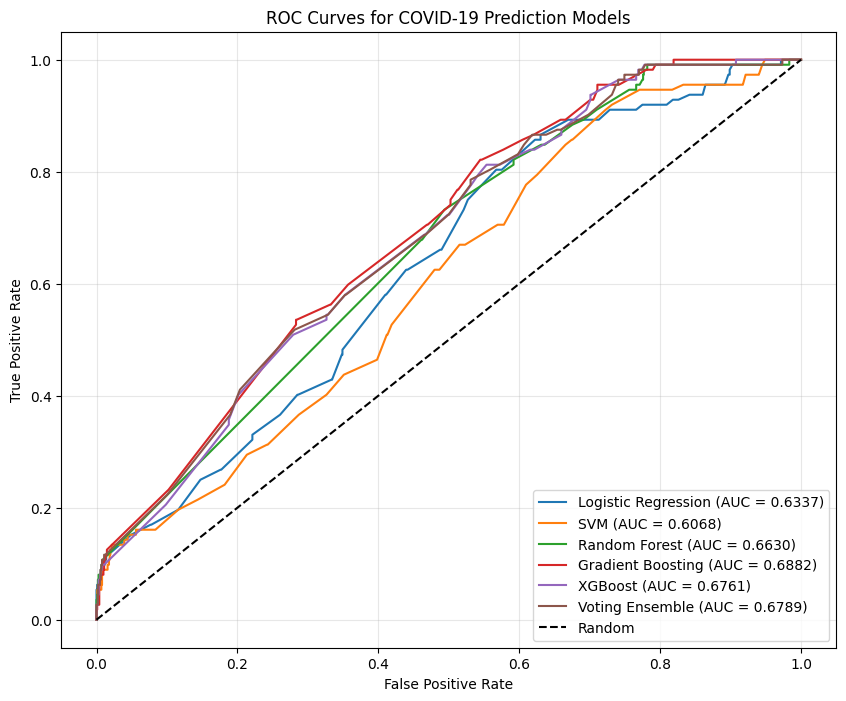

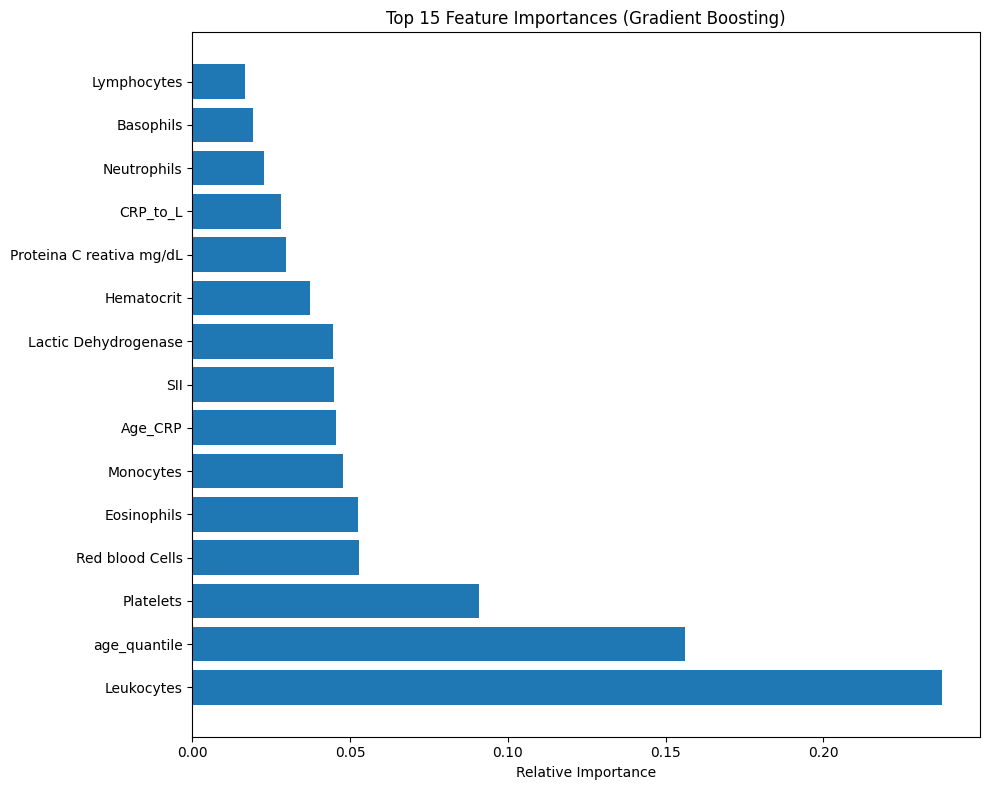


COMPARISON WITH ORIGINAL RESULTS
Original best model (Gradient Boosting): AUC = 0.672
New best model (Gradient Boosting): AUC = 0.6882
Improvement: 2.42%


In [8]:
# %% [markdown]
# # Improved COVID-19 Prediction Model
# 
# This notebook implements improvements to the COVID-19 prediction model based on recent literature.

# %% [Cell 1] - Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import roc_curve, auc, confusion_matrix, classification_report, roc_auc_score
import xgboost as xgb
import warnings

warnings.filterwarnings('ignore')

# %% [Cell 2] - Load and Prepare Data
def load_data(file_path):
    """Load Excel data and prepare it for COVID-19 prediction"""
    # Read the data
    print(f"Loading data from {file_path}...")
    df = pd.read_excel(file_path)
    
    # Rename columns to simpler names
    column_mapping = {
        'Patient age quantile': 'age_quantile',
        'SARS-Cov-2 exam result': 'covid_result',
        'Patient addmited to regular ward (1=yes, 0=no)': 'admitted_regular',
        'Patient addmited to semi-intensive unit (1=yes, 0=no)': 'admitted_semi',
        'Patient addmited to intensive care unit (1=yes, 0=no)': 'admitted_icu'
    }
    
    # Only rename columns that exist in the dataframe
    rename_dict = {k: v for k, v in column_mapping.items() if k in df.columns}
    df = df.rename(columns=rename_dict)
    
    # Create Task 1 dataset (COVID-19 prediction)
    task1_df = df.copy()
    task1_df['target'] = (task1_df['covid_result'] == 'positive').astype(int)
    
    # Add viral test binary features
    virus_features = ['Influenza A', 'Influenza B', 'Respiratory Syncytial Virus']
    for feature in virus_features:
        if feature in task1_df.columns:
            task1_df[f'{feature}_binary'] = task1_df[feature].map(
                lambda x: 1 if x == 'detected' else 0 if x == 'not_detected' else np.nan
            )
    
    print(f"Dataset shape: {task1_df.shape}")
    print(f"COVID-19 positive cases: {task1_df['target'].sum()} ({task1_df['target'].mean()*100:.2f}%)")
    
    return task1_df

# %% [Cell 3] - Feature Selection Based on Literature
def get_literature_features():
    """Select relevant features based on clinical literature"""
    # Original features from your implementation
    base_features = [
        'age_quantile',
        'Leukocytes',         
        'Platelets',          
        'Lymphocytes',        
        'Neutrophils',        
        'Monocytes',          
        'Eosinophils',        
        'Hemoglobin',         
        'Hematocrit',
        'Red blood Cells',
        'Mean platelet volume ',
        'Proteina C reativa mg/dL'  
    ]
    
    # Additional features from newer papers
    additional_features = [
        'Procalcitonin',
        'Basophils',
        'Ferritin',
        'Lactic Dehydrogenase'
    ]
    
    # Combine all features
    all_features = base_features + additional_features
    
    # Return features that exist in the dataset
    return all_features

# %% [Cell 4] - Advanced Feature Engineering
def create_clinical_ratios(X_train, X_test):
    """Create advanced clinical ratios based on literature"""
    # Make copies to avoid modifying originals
    X_train_new = X_train.copy()
    X_test_new = X_test.copy()
    
    # Helper function for safe division
    def safe_ratio(a, b, epsilon=0.001):
        return a / (b + epsilon)
    
    # Create ratios if columns exist
    
    # 1. From original implementation
    if 'Neutrophils' in X_train.columns and 'Lymphocytes' in X_train.columns:
        # Neutrophil-to-Lymphocyte Ratio (NLR) - strong COVID-19 predictor
        X_train_new['NLR'] = safe_ratio(X_train_new['Neutrophils'], X_train_new['Lymphocytes'])
        X_test_new['NLR'] = safe_ratio(X_test_new['Neutrophils'], X_test_new['Lymphocytes'])
    
    if 'Platelets' in X_train.columns and 'Lymphocytes' in X_train.columns:
        # Platelet-to-Lymphocyte Ratio (PLR)
        X_train_new['PLR'] = safe_ratio(X_train_new['Platelets'], X_train_new['Lymphocytes'])
        X_test_new['PLR'] = safe_ratio(X_test_new['Platelets'], X_test_new['Lymphocytes'])
    
    # 2. New ratios from recent literature
    if 'Neutrophils' in X_train.columns and 'Monocytes' in X_train.columns:
        # Neutrophil-to-Monocyte Ratio (NMR)
        X_train_new['NMR'] = safe_ratio(X_train_new['Neutrophils'], X_train_new['Monocytes'])
        X_test_new['NMR'] = safe_ratio(X_test_new['Neutrophils'], X_test_new['Monocytes'])
    
    if 'Proteina C reativa mg/dL' in X_train.columns and 'Lymphocytes' in X_train.columns:
        # CRP-to-Lymphocyte Ratio (CRP/L)
        X_train_new['CRP_to_L'] = safe_ratio(X_train_new['Proteina C reativa mg/dL'], X_train_new['Lymphocytes'])
        X_test_new['CRP_to_L'] = safe_ratio(X_test_new['Proteina C reativa mg/dL'], X_test_new['Lymphocytes'])
    
    # 3. Composite inflammation scores
    if all(x in X_train.columns for x in ['Platelets', 'Neutrophils', 'Lymphocytes']):
        # Systemic Immune-Inflammation Index (SII)
        X_train_new['SII'] = X_train_new['Platelets'] * safe_ratio(X_train_new['Neutrophils'], X_train_new['Lymphocytes'])
        X_test_new['SII'] = X_test_new['Platelets'] * safe_ratio(X_test_new['Neutrophils'], X_test_new['Lymphocytes'])
    
    # 4. Age interactions
    if 'Proteina C reativa mg/dL' in X_train.columns and 'age_quantile' in X_train.columns:
        X_train_new['Age_CRP'] = X_train_new['age_quantile'] * X_train_new['Proteina C reativa mg/dL']
        X_test_new['Age_CRP'] = X_test_new['age_quantile'] * X_test_new['Proteina C reativa mg/dL']
    
    return X_train_new, X_test_new

# %% [Cell 5] - Improved Preprocessing Pipeline
def preprocess_data(df, selected_features, test_size=0.2, random_state=42):
    """Preprocess data with proper train/test split to prevent data leakage"""
    # First split into train and test
    train_df, test_df = train_test_split(
        df, test_size=test_size, random_state=random_state, 
        stratify=df['target']  # Ensure balanced splits
    )
    
    print(f"Training set: {len(train_df)} samples")
    print(f"Testing set: {len(test_df)} samples")
    
    # Filter to available features
    available_features = [f for f in selected_features if f in df.columns]
    print(f"Using {len(available_features)} available features")
    
    # Filter to rows with at least one lab value
    def has_any_lab_value(row):
        return row[available_features].notna().any()
    
    train_filtered = train_df[train_df.apply(has_any_lab_value, axis=1)].copy()
    test_filtered = test_df[test_df.apply(has_any_lab_value, axis=1)].copy()
    
    print(f"After filtering - Training set: {len(train_filtered)} samples")
    print(f"After filtering - Testing set: {len(test_filtered)} samples")
    
    # Extract features and target
    X_train = train_filtered[available_features].copy()
    y_train = train_filtered['target'].copy()
    
    X_test = test_filtered[available_features].copy()
    y_test = test_filtered['target'].copy()
    
    # Create missing indicators
    for feature in available_features:
        if feature != 'age_quantile':  # Skip age which should be complete
            X_train[f'{feature}_missing'] = X_train[feature].isna().astype(int)
            X_test[f'{feature}_missing'] = X_test[feature].isna().astype(int)
    
    # Group missingness indicators
    # CBC group
    cbc_features = [f for f in available_features if f in [
        'Leukocytes', 'Platelets', 'Lymphocytes', 'Neutrophils', 
        'Monocytes', 'Eosinophils', 'Hemoglobin', 'Hematocrit', 'Red blood Cells'
    ]]
    
    if len(cbc_features) > 1:
        X_train['CBC_missing_count'] = X_train[cbc_features].isna().sum(axis=1)
        X_test['CBC_missing_count'] = X_test[cbc_features].isna().sum(axis=1)
    
    # Impute missing values
    imputer = SimpleImputer(strategy='median')
    
    # Fit on training set only to prevent data leakage
    X_train_imputed = pd.DataFrame(
        imputer.fit_transform(X_train),
        columns=X_train.columns,
        index=X_train.index
    )
    
    # Transform test set using training set statistics
    X_test_imputed = pd.DataFrame(
        imputer.transform(X_test),
        columns=X_test.columns,
        index=X_test.index
    )
    
    # Standardization - fit only on training data
    scaler = RobustScaler()  # More robust to outliers
    X_train_scaled = pd.DataFrame(
        scaler.fit_transform(X_train_imputed),
        columns=X_train_imputed.columns,
        index=X_train_imputed.index
    )
    
    X_test_scaled = pd.DataFrame(
        scaler.transform(X_test_imputed),
        columns=X_test_imputed.columns,
        index=X_test_imputed.index
    )
    
    # Create clinical ratios
    X_train_final, X_test_final = create_clinical_ratios(X_train_scaled, X_test_scaled)
    
    return X_train_final, X_test_final, y_train, y_test

# %% [Cell 6] - Model Training with Improved Handling
def train_models(X_train, X_test, y_train, y_test, random_state=42):
    """Train models with cross-validation and proper evaluation"""
    # Calculate class weights
    n_pos = y_train.sum()
    n_neg = len(y_train) - n_pos
    class_weight = n_neg / n_pos if n_pos > 0 else 1.0
    
    print(f"Class distribution: {n_pos} positive, {n_neg} negative (weight={class_weight:.2f})")
    
    # Define models with improved parameters
    models = {
        'Logistic Regression': LogisticRegression(
            max_iter=1000, 
            class_weight='balanced',
            C=0.1,  # Stronger regularization for sparse data
            solver='liblinear',  # Better for small datasets
            random_state=random_state
        ),
        'SVM': SVC(
            probability=True,
            class_weight='balanced',
            kernel='rbf',  # Recommended for COVID-19 by Mei et al.
            C=1.0,
            gamma='scale',
            random_state=random_state
        ),
        'Random Forest': RandomForestClassifier(
            n_estimators=100, 
            class_weight='balanced',
            max_depth=5,
            min_samples_leaf=5,
            random_state=random_state
        ),
        'Gradient Boosting': GradientBoostingClassifier(
            n_estimators=100, 
            learning_rate=0.05,
            max_depth=3,
            subsample=0.8,
            random_state=random_state
        ),
        'XGBoost': xgb.XGBClassifier(
            n_estimators=100, 
            max_depth=3, 
            learning_rate=0.05,
            scale_pos_weight=class_weight,
            subsample=0.8, 
            random_state=random_state
        )
    }
    
    # Cross-validation
    cv_results = {}
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)
    
    print("\nCross-validation results:")
    for name, model in models.items():
        cv_scores = cross_val_score(model, X_train, y_train, cv=skf, scoring='roc_auc')
        cv_results[name] = {
            'mean_auc': cv_scores.mean(),
            'std_auc': cv_scores.std()
        }
        print(f"{name}: AUC = {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
    
    # Train models on full training set and evaluate on test set
    test_results = {}
    
    print("\nTest set evaluation:")
    for name, model in models.items():
        # Train on full training set
        model.fit(X_train, y_train)
        
        # Predict probabilities
        y_pred_proba = model.predict_proba(X_test)[:, 1]
        
        # Find optimal threshold from ROC curve
        fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
        optimal_idx = np.argmax(tpr - fpr)
        optimal_threshold = thresholds[optimal_idx]
        
        # Apply optimal threshold
        y_pred = (y_pred_proba >= optimal_threshold).astype(int)
        
        # Calculate metrics
        roc_auc = roc_auc_score(y_test, y_pred_proba)
        
        # Confusion matrix
        tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
        sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
        f1 = 2 * tp / (2 * tp + fp + fn) if (2 * tp + fp + fn) > 0 else 0
        
        test_results[name] = {
            'model': model,
            'roc_auc': roc_auc,
            'sensitivity': sensitivity,
            'specificity': specificity,
            'f1': f1,
            'optimal_threshold': optimal_threshold,
            'y_pred_proba': y_pred_proba,
            'y_pred': y_pred
        }
        
        print(f"{name}: AUC={roc_auc:.4f}, Sens={sensitivity:.4f}, Spec={specificity:.4f}, F1={f1:.4f}")
        
        # Extract feature importances if available
        if hasattr(model, 'feature_importances_'):
            importances = model.feature_importances_
            indices = np.argsort(importances)[-10:]  # Top 10 features
            print(f"Top features: {[X_train.columns[i] for i in indices[::-1]]}")
    
    # Create and evaluate voting ensemble
    best_models = sorted(test_results.items(), key=lambda x: x[1]['roc_auc'], reverse=True)[:3]
    best_model_names = [m[0] for m in best_models]
    
    print(f"\nCreating ensemble with best models: {best_model_names}")
    
    # Create estimators list
    estimators = []
    weights = []
    
    for model_name in best_model_names:
        model_key = model_name.lower().replace(' ', '_')
        estimators.append((model_key, models[model_name]))
        weights.append(test_results[model_name]['roc_auc'])
    
    # Create and train voting ensemble
    voting_ensemble = VotingClassifier(
        estimators=estimators,
        voting='soft',
        weights=weights
    )
    
    voting_ensemble.fit(X_train, y_train)
    
    # Evaluate ensemble
    y_pred_proba = voting_ensemble.predict_proba(X_test)[:, 1]
    
    # Find optimal threshold
    fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
    optimal_idx = np.argmax(tpr - fpr)
    optimal_threshold = thresholds[optimal_idx]
    
    # Apply optimal threshold
    y_pred = (y_pred_proba >= optimal_threshold).astype(int)
    
    # Calculate metrics
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    
    # Confusion matrix
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    f1 = 2 * tp / (2 * tp + fp + fn) if (2 * tp + fp + fn) > 0 else 0
    
    # Add to results
    test_results['Voting Ensemble'] = {
        'model': voting_ensemble,
        'roc_auc': roc_auc,
        'sensitivity': sensitivity,
        'specificity': specificity,
        'f1': f1,
        'optimal_threshold': optimal_threshold,
        'y_pred_proba': y_pred_proba,
        'y_pred': y_pred
    }
    
    print(f"Voting Ensemble: AUC={roc_auc:.4f}, Sens={sensitivity:.4f}, Spec={specificity:.4f}, F1={f1:.4f}")
    
    # Find best model
    best_model_name = max(test_results.items(), key=lambda x: x[1]['roc_auc'])[0]
    print(f"\nBest model: {best_model_name} (AUC = {test_results[best_model_name]['roc_auc']:.4f})")
    
    return test_results, cv_results

# %% [Cell 7] - Plot Results
def plot_results(test_results):
    """Plot ROC curves for all models"""
    plt.figure(figsize=(10, 8))
    
    for name, results in test_results.items():
        if 'y_pred_proba' in results and 'model' in results:
            y_test = results.get('y_test', None)
            y_pred_proba = results['y_pred_proba']
            
            # Calculate ROC curve
            fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
            roc_auc = results['roc_auc']
            
            plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.4f})")
    
    # Plot the random line
    plt.plot([0, 1], [0, 1], 'k--', label='Random')
    
    # Add labels and legend
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curves for COVID-19 Prediction Models')
    plt.legend(loc='lower right')
    plt.grid(True, alpha=0.3)
    
    plt.show()

# %% [Cell 8] - Plot Feature Importance
def plot_feature_importance(X_train, model, model_name, top_n=15):
    """Plot top feature importances for a model"""
    if hasattr(model, 'feature_importances_'):
        importances = model.feature_importances_
    elif hasattr(model, 'coef_'):
        importances = np.abs(model.coef_[0])
    else:
        print(f"No feature importances available for {model_name}")
        return
    
    # Sort features by importance
    indices = np.argsort(importances)[-top_n:]
    
    plt.figure(figsize=(10, 8))
    plt.title(f'Top {top_n} Feature Importances ({model_name})')
    plt.barh(range(top_n), importances[indices], align='center')
    plt.yticks(range(top_n), [X_train.columns[i] for i in indices])
    plt.xlabel('Relative Importance')
    plt.gca().invert_yaxis()  # Highest importance at the top
    plt.tight_layout()
    plt.show()

# %% [Cell 9] - Full Pipeline Function
def run_covid_prediction(file_path, random_state=42):
    """Run the complete COVID-19 prediction pipeline"""
    print("=" * 50)
    print("IMPROVED COVID-19 PREDICTION MODEL")
    print("=" * 50)
    
    # Step 1: Load data
    print("\nStep 1: Loading data...")
    df = load_data(file_path)
    
    # Step 2: Select features
    print("\nStep 2: Selecting features...")
    features = get_literature_features()
    
    # Add binary viral features to the features list
    viral_features = [col for col in df.columns if '_binary' in col]
    all_features = features + viral_features
    
    # Step 3: Preprocess data
    print("\nStep 3: Preprocessing data...")
    X_train, X_test, y_train, y_test = preprocess_data(
        df, all_features, test_size=0.2, random_state=random_state
    )
    
    # Step 4: Train and evaluate models
    print("\nStep 4: Training models...")
    test_results, cv_results = train_models(
        X_train, X_test, y_train, y_test, random_state=random_state
    )
    
    # Step 5: Plot results
    print("\nStep 5: Plotting results...")
    
    # Add y_test to each model's results for plotting
    for model_name in test_results:
        test_results[model_name]['y_test'] = y_test
    
    plot_results(test_results)
    
    # Plot feature importance for best model
    best_model_name = max(test_results.items(), key=lambda x: x[1]['roc_auc'])[0]
    if best_model_name and 'model' in test_results[best_model_name]:
        best_model = test_results[best_model_name]['model']
        plot_feature_importance(X_train, best_model, best_model_name)
    
    # Compare with original results
    print("\n" + "=" * 50)
    print("COMPARISON WITH ORIGINAL RESULTS")
    print("=" * 50)
    print("Original best model (Gradient Boosting): AUC = 0.672")
    
    new_auc = test_results[best_model_name]['roc_auc']
    improvement = (new_auc - 0.672) / 0.672 * 100
    
    print(f"New best model ({best_model_name}): AUC = {new_auc:.4f}")
    print(f"Improvement: {improvement:.2f}%")
    
    return test_results, X_train, X_test, y_train, y_test

# %% [Cell 10] - Execute the Code
# Execute this cell to run the entire pipeline
file_path = "dataset.xlsx"  # Update with your file path
results, X_train, X_test, y_train, y_test = run_covid_prediction(file_path)